# Primero se importan las librerias necesarias

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1-Cargar los datasets procesados

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

# 2-Separar caracteristicas (X) y etiquetas (y)

In [3]:
X_train = train_df.drop(columns=['target']).values
y_train = train_df['target'].values

In [4]:
X_test = test_df.drop(columns=['target']).values
y_test = test_df['target'].values

# Guardamos el numero de variables de entrada para definir la primera capa

In [5]:
num_features = X_train.shape[1]

# Escalado

## Librerias necesarias para el escalado

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](18,)","[1.,1.,1.,...,1.,1.,1.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](18,)","[0.,0.,0.,...,0.,0.,0.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](18,)","[1.,1.,1.,...,1.,1.,1.]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](18,)","[0.,0.,0.,...,0.,0.,0.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,1120
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](18,)","[1.,1.,1.,...,1.,1.,1.]"


In [17]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train.shape

(1120, 18)

In [19]:
X_test.shape

(200, 18)

In [20]:
X_train

array([[0.        , 0.57142857, 0.5       , ..., 0.        , 0.66666667,
        0.        ],
       [1.        , 0.14285714, 0.5       , ..., 0.        , 0.66666667,
        0.        ],
       [0.        , 0.57142857, 1.        , ..., 0.33333333, 0.66666667,
        0.        ],
       ...,
       [0.40794969, 0.14924529, 0.30596227, ..., 0.        , 0.92538364,
        0.        ],
       [0.72606979, 0.57142857, 0.54455234, ..., 0.05940312, 0.72606979,
        0.        ],
       [0.        , 0.59607733, 0.83627066, ..., 0.        , 0.66666667,
        0.        ]], shape=(1120, 18))

In [21]:
X_train.max()

np.float64(1.0)

# Creacion del modelo

## Librerias necesarias para la creacion del modelo 

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout

In [23]:
X_train.shape

(1120, 18)

In [55]:
model = Sequential()
# Elegir número de capas (layers)
num_neuronas = X_train.shape[1]
model.add(Dense(units=num_neuronas,activation='relu'))

model.add(Dense(units=int(np.round(num_neuronas/2)),activation='relu'))

model.add(Dense(units=1,activation='sigmoid'))

# Para clasificación binaria "binary_crossentropy"
model.compile(loss='binary_crossentropy', optimizer='adam')

# Entrenamiento del modelo

## Ejemplo 1: Valor alto de epochs y overfitting

In [56]:
model.fit(x=X_train,
          y=y_train,
          epochs=600,
          validation_data=(X_test, y_test), verbose=1
          )

Epoch 1/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.7385 - val_loss: 0.7257
Epoch 2/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6867 - val_loss: 0.6942
Epoch 3/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6685 - val_loss: 0.6689
Epoch 4/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6474 - val_loss: 0.6435
Epoch 5/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6210 - val_loss: 0.6088
Epoch 6/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5954 - val_loss: 0.5859
Epoch 7/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5737 - val_loss: 0.5480
Epoch 8/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5582 - val_loss: 0.5765
Epoch 9/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5468 - val_loss: 0.5618
Epoch 10/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5402 - val_loss: 0.5544
Epoch 11/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5355 - val_loss: 0.5555
Epoch 12/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

<Axes: >

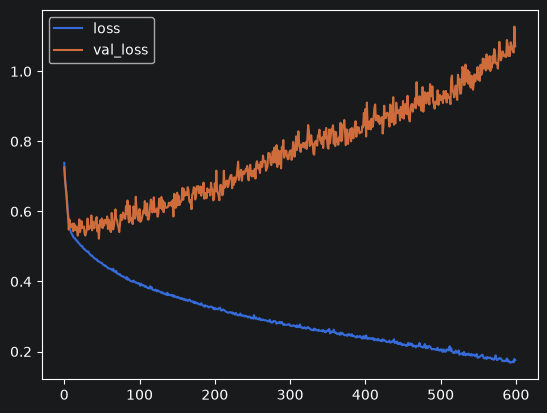

In [57]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## Ejemplo 2: Early Stopping

## Librerias necesarias para el Early Stopping

In [58]:
from tensorflow.keras.callbacks import EarlyStopping

In [59]:
model = Sequential()
model.add(Dense(units=num_neuronas,activation='relu'))
model.add(Dense(units=int(np.round(num_neuronas/2)),activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [60]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [61]:
model.fit(x=X_train,
          y=y_train,
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6878 - val_loss: 0.6640
Epoch 2/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6741 - val_loss: 0.6422
Epoch 3/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6547 - val_loss: 0.6154
Epoch 4/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6302 - val_loss: 0.5809
Epoch 5/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6051 - val_loss: 0.5814
Epoch 6/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5804 - val_loss: 0.5553
Epoch 7/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5628 - val_loss: 0.5686
Epoch 8/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5501 - val_loss: 0.5474
Epoch 9/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5393 - val_loss: 0.5413
Epoch 10/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5330 - val_loss: 0.5510
Epoch 11/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5287 - val_loss: 0.5573
Epoch 12/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

<Axes: >

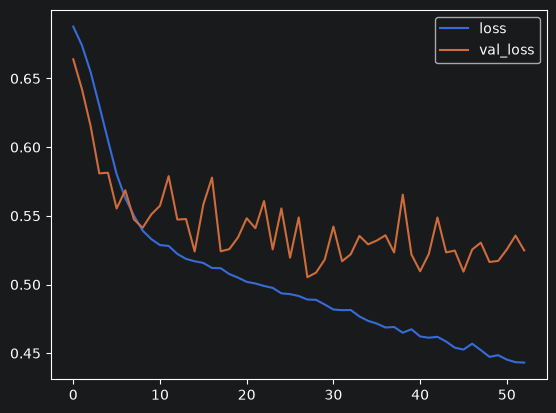

In [62]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## Ejemplo 3: Añadir DropOut Layers

## Librerias necesarias para añadir el DropOut Layers

In [63]:
from tensorflow.keras.layers import Dropout

In [64]:
model = Sequential()

model.add(Dense(units=num_neuronas,activation='relu'))
model.add(Dropout(0.5)) #la mitad de las neuronas en cada epoch para esta capa

model.add(Dense(units=int(np.round(num_neuronas/2)),activation='relu'))
model.add(Dropout(0.5)) #la mitad de las neuronas en cada epoch para esta capa

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [65]:
model.fit(x=X_train,
          y=y_train,
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.7247 - val_loss: 0.7170
Epoch 2/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7039 - val_loss: 0.6980
Epoch 3/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6840 - val_loss: 0.6895
Epoch 4/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6836 - val_loss: 0.6890
Epoch 5/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6794 - val_loss: 0.6837
Epoch 6/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6811 - val_loss: 0.6820
Epoch 7/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6846 - val_loss: 0.6819
Epoch 8/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6737 - val_loss: 0.6681
Epoch 9/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6709 - val_loss: 0.6703
Epoch 10/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6712 - val_loss: 0.6696
Epoch 11/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6703 - val_loss: 0.6586
Epoch 12/600
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0

<Axes: >

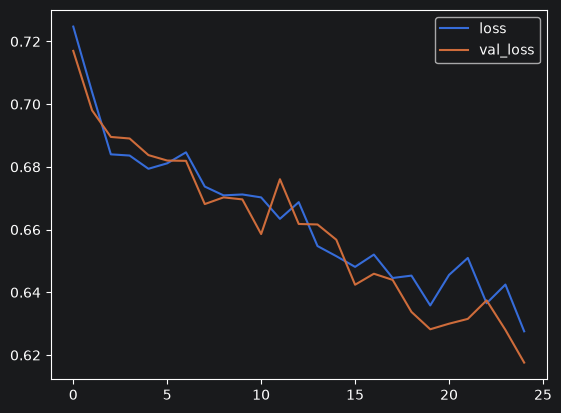

In [66]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

# Evaluacion del modelo

## Librerias necesarias para la evaluacion del modelo

In [67]:
from sklearn.metrics import classification_report,confusion_matrix

## Prediccion sobre el conjunto de Test

In [68]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [69]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.86      0.70      0.77       140
           1       0.51      0.73      0.60        60

    accuracy                           0.71       200
   macro avg       0.69      0.72      0.69       200
weighted avg       0.76      0.71      0.72       200



In [70]:
print(confusion_matrix(y_test,predictions))

[[98 42]
 [16 44]]


# Guardar y cargar el modelo para posterior uso

In [71]:
from tensorflow.keras.models import load_model
model.save('modelo_pred_ar.h5')